In [1]:
from utils import get_all
from statistical_significance import compare_accuracies, compare_accuracies_v2, compare_accuracies_v3

import pandas as pd
import numpy as np

df = get_all()
df.head()

GSM8K
gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx
DP-Reflection
qwen3_1.7b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
deepseek-r1_1.5b.xlsx
ReAct
qwen3_1.7b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
llama3.2_1b.xlsx
ReWOO
gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx
DP
gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx
smollm2_1.7b.xlsx
DP-Reflection
qwen3_1.7b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
deepseek-r1_1.5b.xlsx
ReAct
qwen3_1.7b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
llama3.2_1b.xlsx
ReWOO
gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2

,Dataset,Method,Model,question,target_answer,is_correct,Error Class,Error Type,reasoning,input_tokens,output_tokens,total_tokens
0,GSM8K,Direktes Prompting,gemma-3-27b-it,Janet‚Äôs ducks lay 16 eggs per day. She eats ...,Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eg...,True,NaN,NaN,Let $E$ be the number of eggs Janet's ducks la...,NaN,NaN,NaN
1,GSM8K,Direktes Prompting,gemma-3-27b-it,A robe takes 2 bolts of blue fiber and half th...,It takes 2/2=<<2/2=1>>1 bolt of white fiber\nS...,True,NaN,NaN,Let the number of bolts of blue fiber be $B$ a...,NaN,NaN,NaN
2,GSM8K,Direktes Prompting,gemma-3-27b-it,Josh decides to try flipping a house. He buys...,The cost of the house and repairs came out to ...,True,NaN,NaN,Let the initial cost of the house be $C = \$80...,NaN,NaN,NaN
3,GSM8K,Direktes Prompting,gemma-3-27b-it,James decides to run 3 sprints 3 times a week....,He sprints 3*3=<<3*3=9>>9 times\nSo he runs 9*...,True,NaN,NaN,Let $s$ be the number of sprints James runs ea...,NaN,NaN,NaN
4,GSM8K,Direktes Prompting,gemma-3-27b-it,"Every day, Wendi feeds each of her chickens th...","If each chicken eats 3 cups of feed per day, t...",True,NaN,NaN,Let $n$ be the number of chickens Wendi has. W...,NaN,NaN,NaN


# Misclassified

In [2]:
df_misc = get_all(include_misclassified=True)
df_misc = df_misc[df_misc["Error Type"] == "Misclassified"]
df_misc.groupby(["Model", "Error Class"]).agg({
    "question": "count",
}).reset_index().sort_values(by="question", ascending=False).head(50)

GSM8K
gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx
DP-Reflection
qwen3_1.7b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
deepseek-r1_1.5b.xlsx
ReAct
qwen3_1.7b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
llama3.2_1b.xlsx
ReWOO
gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx
DP
gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx
smollm2_1.7b.xlsx
DP-Reflection
qwen3_1.7b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
deepseek-r1_1.5b.xlsx
ReAct
qwen3_1.7b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
llama3.2_1b.xlsx
ReWOO
gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2

,Model,Error Class,question
6,llama3.2_1b,Misclassified,23
10,qwen2.5_0.5b,Misclassified,23
0,deepseek-r1:1.5b,Misclassified,21
1,deepseek-r1_1.5b,Misclassified,18
13,qwen3_0.6b,Misclassified,12
9,qwen2.5:0.5b,Misclassified,9
4,gemma3_1b,Misclassified,9
7,qwen2-math:1.5b,Misclassified,8
2,gemma-3-27b-it,Misclassified,8
14,qwen3_1.7b,Misclassified,7


In [3]:
overall_misc_rate = len(df_misc) / len(df)
print(f"Total misclassified examples: {len(df_misc)}")
print(f"Total examples: {len(df)}")
print(f"Overall misclassification rate: {overall_misc_rate:.2%}")

Total misclassified examples: 173
Total examples: 15468
Overall misclassification rate: 1.12%


# Accuracy

## Overview

In [4]:
df_acc = df.groupby(["Dataset", "Method", "Model"]).agg({
    "is_correct": "mean",
}).reset_index()
# pivot to have Method as Columns
df_acc = df_acc.pivot_table(index=["Model", "Dataset"], columns="Method", values="is_correct", fill_value=np.nan).reset_index()
df_acc.head(50)

/var/folders/rl/3ygx2m4n1w747bxzh4qvfjs00000gn/T/ipykernel_26554/4005652464.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_acc = df_acc.pivot_table(index=["Model", "Dataset"], columns="Method", values="is_correct", fill_value=np.nan).reset_index()


Method,Model,Dataset,DP-Reflection,Direktes Prompting,ReAct,ReWOO
0,deepseek-r1:1.5b,GSM8K,0.660000,0.733333,NaN,0.773333
1,deepseek-r1_1.5b,SVAMP,0.781690,0.834507,NaN,0.866197
2,gemma-3-27b-it,GSM8K,NaN,0.973333,NaN,0.890000
3,gemma-3-27b-it,SVAMP,NaN,0.989437,NaN,0.880282
4,gemma3:1b,GSM8K,NaN,0.586667,NaN,0.113333
5,gemma3_1b,SVAMP,NaN,0.693662,NaN,0.274648
6,llama3.2:1b,GSM8K,NaN,0.506667,0.240000,0.040000
7,llama3.2_1b,SVAMP,NaN,0.683099,0.380282,0.232394
8,qwen2-math:1.5b,GSM8K,NaN,0.823333,NaN,0.003333
9,qwen2-math_1.5b,SVAMP,NaN,0.936620,NaN,0.010563


## Sorted

In [6]:
df_acc = df.groupby(["Dataset", "Model", "Method"]).agg({
    "is_correct": "mean",
}).reset_index().sort_values(by="is_correct", ascending=False)
df_acc

,Dataset,Model,Method,is_correct
25,SVAMP,google/gemma-3-27b-it,Direct Prompting,0.989437
0,GSM8K,google/gemma-3-27b-it,Direct Prompting,0.973333
46,SVAMP,ollama/qwen3_1.7b,ReAct,0.961268
34,SVAMP,ollama/qwen2-math_1.5b,Direct Prompting,0.93662
44,SVAMP,ollama/qwen3_1.7b,DP-Reflection,0.93617
47,SVAMP,ollama/qwen3_1.7b,ReWOO,0.933099
1,GSM8K,google/gemma-3-27b-it,ReWOO,0.89
26,SVAMP,google/gemma-3-27b-it,ReWOO,0.880282
28,SVAMP,ollama/deepseek-r1_1.5b,ReWOO,0.866197
19,GSM8K,ollama/qwen3_1.7b,DP-Reflection,0.86


## Alphabetical

In [7]:
df_acc = df.groupby(["Dataset", "Model", "Method"]).agg({
    "is_correct": "mean",
}).reset_index().sort_values(by="Model", ascending=True)
df_acc

,Dataset,Model,Method,is_correct
0,GSM8K,google/gemma-3-27b-it,Direct Prompting,0.973333
25,SVAMP,google/gemma-3-27b-it,Direct Prompting,0.989437
26,SVAMP,google/gemma-3-27b-it,ReWOO,0.880282
1,GSM8K,google/gemma-3-27b-it,ReWOO,0.89
3,GSM8K,ollama/deepseek-r1_1.5b,ReWOO,0.773333
28,SVAMP,ollama/deepseek-r1_1.5b,ReWOO,0.866197
27,SVAMP,ollama/deepseek-r1_1.5b,Direct Prompting,0.834507
2,GSM8K,ollama/deepseek-r1_1.5b,Direct Prompting,0.733333
4,GSM8K,ollama/gemma3_1b,Direct Prompting,0.586667
5,GSM8K,ollama/gemma3_1b,ReWOO,0.113333


## Statistical Significance

### Per Model

In [8]:
df_acc.to_records()

rec.array([( 0, 'GSM8K', 'google/gemma-3-27b-it', 'Direct Prompting', 0.9733333333333334),
           (25, 'SVAMP', 'google/gemma-3-27b-it', 'Direct Prompting', 0.9894366197183099),
           (26, 'SVAMP', 'google/gemma-3-27b-it', 'ReWOO', 0.8802816901408451),
           ( 1, 'GSM8K', 'google/gemma-3-27b-it', 'ReWOO', 0.89),
           ( 3, 'GSM8K', 'ollama/deepseek-r1_1.5b', 'ReWOO', 0.7733333333333333),
           (28, 'SVAMP', 'ollama/deepseek-r1_1.5b', 'ReWOO', 0.8661971830985915),
           (27, 'SVAMP', 'ollama/deepseek-r1_1.5b', 'Direct Prompting', 0.8345070422535211),
           ( 2, 'GSM8K', 'ollama/deepseek-r1_1.5b', 'Direct Prompting', 0.7333333333333333),
           ( 4, 'GSM8K', 'ollama/gemma3_1b', 'Direct Prompting', 0.5866666666666667),
           ( 5, 'GSM8K', 'ollama/gemma3_1b', 'ReWOO', 0.11333333333333333),
           (29, 'SVAMP', 'ollama/gemma3_1b', 'Direct Prompting', 0.6936619718309859),
           (30, 'SVAMP', 'ollama/gemma3_1b', 'ReWOO', 0.2746478873239437),

In [9]:
n_svamp = df[df["Dataset"] == "SVAMP"]["question"].nunique()
n_gsm8k = df[df["Dataset"] == "GSM8K"]["question"].nunique()
data = {}
for idx, dataset, model, method, is_correct_mean in df_acc.to_records():
    if model not in data:
        data[model] = {}
    if method not in data[model]:
        data[model][method] = {}
    data[model][method][dataset] = is_correct_mean

data

{'google/gemma-3-27b-it': {'Direct Prompting': {'GSM8K': 0.9733333333333334,
   'SVAMP': 0.9894366197183099},
  'ReWOO': {'SVAMP': 0.8802816901408451, 'GSM8K': 0.89}},
 'ollama/deepseek-r1_1.5b': {'ReWOO': {'GSM8K': 0.7733333333333333,
   'SVAMP': 0.8661971830985915},
  'Direct Prompting': {'SVAMP': 0.8345070422535211,
   'GSM8K': 0.7333333333333333}},
 'ollama/gemma3_1b': {'Direct Prompting': {'GSM8K': 0.5866666666666667,
   'SVAMP': 0.6936619718309859},
  'ReWOO': {'GSM8K': 0.11333333333333333, 'SVAMP': 0.2746478873239437}},
 'ollama/llama3.2_1b': {'Direct Prompting': {'GSM8K': 0.5066666666666667,
   'SVAMP': 0.6830985915492958},
  'ReAct': {'GSM8K': 0.24, 'SVAMP': 0.38028169014084506},
  'ReWOO': {'GSM8K': 0.04, 'SVAMP': 0.2323943661971831}},
 'ollama/qwen2-math_1.5b': {'ReWOO': {'SVAMP': 0.01056338028169014,
   'GSM8K': 0.0033333333333333335},
  'Direct Prompting': {'GSM8K': 0.8233333333333334,
   'SVAMP': 0.9366197183098591}},
 'ollama/qwen2.5_0.5b': {'DP-Reflection': {'SVAMP': 0.

In [10]:
significant_results = []
insignificant_results = []

for model, methods in data.items():
    for method, items in methods.items():
        gsm8k = "GSM8K"
        svamp = "SVAMP"
        print(items)
        score_gsm8k = items.get(gsm8k, None)
        score_svamp = items.get(svamp, None)
        if score_gsm8k is None or score_svamp is None:
            print(f"Skipping {model} {method} due to missing scores for one of the datasets.")
            continue
        r = compare_accuracies_v3(
            p1=score_gsm8k,
            n1=n_gsm8k,
            p2=score_svamp,
            n2=n_svamp
        )
        if r.is_significant:
            if score_gsm8k < score_svamp:
                dataset1, score1, dataset2, score2 = svamp, score_svamp, gsm8k, score_gsm8k
            else:
                dataset1, score1, dataset2, score2 = gsm8k, score_gsm8k, svamp, score_svamp
            
            significant_results.append({
                "model": model,
                "method": method,
                "dataset1": dataset1,
                "score1": score1,
                "dataset2": dataset2,
                "score2": score2,
                "is_significant": r.is_significant,
            })
        else:
            if score_gsm8k < score_svamp:
                dataset1, score1, dataset2, score2 = svamp, score_svamp, gsm8k, score_gsm8k
            else:
                dataset1, score1, dataset2, score2 = gsm8k, score_gsm8k, svamp, score_svamp
            
            insignificant_results.append({
                "model": model,
                "method": method,
                "dataset1": dataset1,
                "score1": score1,
                "dataset2": dataset2,
                "score2": score2,
                "is_significant": r.is_significant,
            })      



{'GSM8K': 0.9733333333333334, 'SVAMP': 0.9894366197183099}
{'SVAMP': 0.8802816901408451, 'GSM8K': 0.89}
{'GSM8K': 0.7733333333333333, 'SVAMP': 0.8661971830985915}
{'SVAMP': 0.8345070422535211, 'GSM8K': 0.7333333333333333}
{'GSM8K': 0.5866666666666667, 'SVAMP': 0.6936619718309859}
{'GSM8K': 0.11333333333333333, 'SVAMP': 0.2746478873239437}
{'GSM8K': 0.5066666666666667, 'SVAMP': 0.6830985915492958}
{'GSM8K': 0.24, 'SVAMP': 0.38028169014084506}
{'GSM8K': 0.04, 'SVAMP': 0.2323943661971831}
{'SVAMP': 0.01056338028169014, 'GSM8K': 0.0033333333333333335}
{'GSM8K': 0.8233333333333334, 'SVAMP': 0.9366197183098591}
{'SVAMP': 0.5035211267605634, 'GSM8K': 0.35}
{'SVAMP': 0.2852112676056338, 'GSM8K': 0.12333333333333334}
{'SVAMP': 0.3380281690140845, 'GSM8K': 0.15666666666666668}
{'SVAMP': 0.5669014084507042, 'GSM8K': 0.4033333333333333}
{'SVAMP': 0.7570422535211268, 'GSM8K': 0.61}
{'SVAMP': 0.8415492957746479, 'GSM8K': 0.6466666666666666}
{'SVAMP': 0.5950704225352113, 'GSM8K': 0.5533333333333333}


In [11]:
significant_results_df = pd.DataFrame.from_records(significant_results)
significant_results_df

,model,method,dataset1,score1,dataset2,score2,is_significant
0,ollama/deepseek-r1_1.5b,ReWOO,SVAMP,0.866197,GSM8K,0.773333,True
1,ollama/deepseek-r1_1.5b,Direct Prompting,SVAMP,0.834507,GSM8K,0.733333,True
2,ollama/gemma3_1b,Direct Prompting,SVAMP,0.693662,GSM8K,0.586667,True
3,ollama/gemma3_1b,ReWOO,SVAMP,0.274648,GSM8K,0.113333,True
4,ollama/llama3.2_1b,Direct Prompting,SVAMP,0.683099,GSM8K,0.506667,True
5,ollama/llama3.2_1b,ReAct,SVAMP,0.380282,GSM8K,0.240000,True
6,ollama/llama3.2_1b,ReWOO,SVAMP,0.232394,GSM8K,0.040000,True
7,ollama/qwen2-math_1.5b,Direct Prompting,SVAMP,0.936620,GSM8K,0.823333,True
8,ollama/qwen2.5_0.5b,DP-Reflection,SVAMP,0.503521,GSM8K,0.350000,True
9,ollama/qwen2.5_0.5b,ReWOO,SVAMP,0.285211,GSM8K,0.123333,True


In [12]:
insignificant_results_df = pd.DataFrame.from_records(insignificant_results)
insignificant_results_df

,model,method,dataset1,score1,dataset2,score2,is_significant
0,google/gemma-3-27b-it,Direct Prompting,SVAMP,0.989437,GSM8K,0.973333,False
1,google/gemma-3-27b-it,ReWOO,GSM8K,0.890000,SVAMP,0.880282,False
2,ollama/qwen2-math_1.5b,ReWOO,SVAMP,0.010563,GSM8K,0.003333,False
3,ollama/qwen3_0.6b,ReWOO,SVAMP,0.595070,GSM8K,0.553333,False


# Error Analysis

Overview

In [27]:
df_err = df.groupby(["Dataset", "Model", "Method", "Error Type", "Error Class"]).agg({
    "question": "count",
}).pivot_table(
    index=["Model", "Method", "Dataset"],
    columns=["Error Type", "Error Class"],
    values="question",
    fill_value=0
).reset_index()

df_err.head(50)

Error Type                     Model            Method Dataset  \
Error Class                                                      
0              google/gemma-3-27b-it  Direct Prompting   GSM8K   
1              google/gemma-3-27b-it  Direct Prompting   SVAMP   
2              google/gemma-3-27b-it             ReWOO   GSM8K   
3              google/gemma-3-27b-it             ReWOO   SVAMP   
4            ollama/deepseek-r1_1.5b  Direct Prompting   GSM8K   
5            ollama/deepseek-r1_1.5b  Direct Prompting   SVAMP   
6            ollama/deepseek-r1_1.5b             ReWOO   GSM8K   
7            ollama/deepseek-r1_1.5b             ReWOO   SVAMP   
8                   ollama/gemma3_1b  Direct Prompting   GSM8K   
9                   ollama/gemma3_1b  Direct Prompting   SVAMP   
10                  ollama/gemma3_1b             ReWOO   GSM8K   
11                  ollama/gemma3_1b             ReWOO   SVAMP   
12                ollama/llama3.2_1b  Direct Prompting   GSM8K   
13                ollama/llama3.2_1b  Direct Prompting   SVAMP   
14                ollama/llama3.2_1b             ReAct   GSM8K   
15                ollama/llama3.2_1b             ReAct   SVAMP   
16                ollama/llama3.2_1b             ReWOO   GSM8K   
17                ollama/llama3.2_1b             ReWOO   SVAMP   
18            ollama/qwen2-math_1.5b  Direct Prompting   GSM8K   
19            ollama/qwen2-math_1.5b  Direct Prompting   SVAMP   
20            ollama/qwen2-math_1.5b             ReWOO   GSM8K   
21            ollama/qwen2-math_1.5b             ReWOO   SVAMP   
22               ollama/qwen2.5_0.5b  Direct Prompting   GSM8K   
23               ollama/qwen2.5_0.5b  Direct Prompting   SVAMP   
24               ollama/qwen2.5_0.5b             ReAct   GSM8K   
25               ollama/qwen2.5_0.5b             ReAct   SVAMP   
26               ollama/qwen2.5_0.5b             ReWOO   GSM8K   
27               ollama/qwen2.5_0.5b             ReWOO   SVAMP   
28                 ollama/qwen3_0.6b  Direct Prompting   GSM8K   
29                 ollama/qwen3_0.6b  Direct Prompting   SVAMP   
30                 ollama/qwen3_0.6b             ReAct   GSM8K   
31                 ollama/qwen3_0.6b             ReAct   SVAMP   
32                 ollama/qwen3_0.6b             ReWOO   GSM8K   
33                 ollama/qwen3_0.6b             ReWOO   SVAMP   
34                 ollama/qwen3_1.7b  Direct Prompting   GSM8K   
35                 ollama/qwen3_1.7b  Direct Prompting   SVAMP   
36                 ollama/qwen3_1.7b             ReAct   GSM8K   
37                 ollama/qwen3_1.7b             ReAct   SVAMP   
38                 ollama/qwen3_1.7b             ReWOO   GSM8K   
39                 ollama/qwen3_1.7b             ReWOO   SVAMP   
40               ollama/smollm2_1.7b  Direct Prompting   SVAMP   
41               ollama/smollm2_360m  Direct Prompting   GSM8K   
42               ollama/smollm2_360m             ReWOO   GSM8K   
43               ollama/smollm2_360m             ReWOO   SVAMP   

Error Type    Execution Error                                        \
Error Class Calculation Error Declines to Answer  Loop Overthinking   
0                         0.0                0.0   0.0          0.0   
1                         0.0                0.0   0.0          1.0   
2                         0.0                0.0   0.0          0.0   
3                         0.0                0.0   1.0          0.0   
4                         0.0                0.0   0.0          9.0   
5                         4.0                0.0   3.0          0.0   
6                         0.0                0.0   1.0         13.0   
7                         1.0                0.0   0.0          0.0   
8                         0.0                0.0  41.0          0.0   
9                         2.0                0.0  53.0          6.0   
10                        0.0                0.0   8.0          0.0   
11                        0.0           

## Statistical Significance

In [64]:
significant_results = []
n = df["ID"].nunique()
data = {}
headers = df_err.columns.tolist()[:-1]

for item in df_err.to_records():
    model = item[1]
    method = item[2]

    if model not in data:
        data[model] = []
    item = list(item)[1:-1]
    data[model].append(item)

for model in data:
    items = data[model]
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            for k in range(3, len(headers)):
                method1 = items[i][1]
                method2 = items[j][1]
                score1 = items[i][k] / n
                score2 = items[j][k] / n
                if method1 == method2:
                    continue
                r = compare_accuracies_v3(
                    p1=score1,
                    n1=n,
                    p2=score2,
                    n2=n
                )
                # print(f"Comparing {method1} vs {method2} for {headers[k]} in {model}: {score1} vs {score2} => is_significant: {r.is_significant}")
                if r.is_significant:
                    if score1 < score2:
                        method1, score1, method2, score2 = method2, score2, method1, score1
                    significant_results.append({
                        "model": model,
                        "Error Class": headers[k],
                        "method1": method1,
                        "score1": score1 * n,
                        "method2": method2,
                        "score2": score2 * n,
                        "is_significant": r.is_significant,
                    })
                    
                
                
significant_results_df = pd.DataFrame.from_records(significant_results)
# Drop all rows where score1 or score2 is 0
significant_results_df = significant_results_df[(significant_results_df["score1"] > 0) & (significant_results_df["score2"] > 0)]

significant_results_df

,model,Error Class,method1,score1,method2,score2,is_significant
0,google/gemma-3-27b-it,"(Execution Error, Wrong Reasoning)",ReWOO,32.0,Direct Prompting,2.0,True
1,ollama/deepseek-r1_1.5b,"(Execution Error, Wrong Reasoning)",Direct Prompting,40.0,ReWOO,13.0,True
4,ollama/gemma3_1b,"(Execution Error, Loop)",Direct Prompting,53.0,ReWOO,2.0,True
6,ollama/gemma3_1b,"(Execution Error, Wrong Reasoning)",ReWOO,172.0,Direct Prompting,26.0,True
9,ollama/llama3.2_1b,"(Execution Error, Wrong Reasoning)",ReAct,163.0,Direct Prompting,79.0,True
12,ollama/llama3.2_1b,"(Execution Error, Wrong Reasoning)",ReWOO,118.0,Direct Prompting,79.0,True
17,ollama/llama3.2_1b,"(Execution Error, Wrong Reasoning)",ReAct,163.0,ReWOO,118.0,True
22,ollama/qwen2.5_0.5b,"(Execution Error, Wrong Reasoning)",ReAct,158.0,Direct Prompting,114.0,True
24,ollama/qwen2.5_0.5b,"(Execution Error, Wrong Reasoning)",ReWOO,168.0,Direct Prompting,114.0,True
28,ollama/qwen2.5_0.5b,"(Tool Error, Tool Error)",ReAct,27.0,ReWOO,6.0,True


Interpretation: 

- **Gemma3 27B**: 
    - Wrong Reasoning: 
        - ReWOO > DP
- **Deepseek**: 
    - Wrong Reasoning: 
        - DP > ReWOO
- **Gemma**:
    - Error Loops: DP > ReWOO
    - Wrong Reasoning: ReWOO > DP
- **Llama**:
    - Wrong Reasoning: 
        - ReWOO > DP
        - ReAct > DP
        - ReWOO > ReAct
- **Qwen 2.5 0.5B**:
    - Wrong Reasoning:
        - ReAct > DP
        - ReWOO > DP
    - Tool Errors:
        - ReAct > ReWOO
- **Qwen3 0.6B**:
    - Overthinking:
        - ReAct > ReWOO
        - DP > ReWOO
    - Wrong Reasoning:
        - ReAct > DP
        - ReWOO > DP
- **Qwen3 1.7B**:
    - Overthinking:
        - DP > ReAct
        - DP > ReWOO

In [65]:
df_err["Model-Method"] = df_err["Model"] + " - " + df_err["Method"]

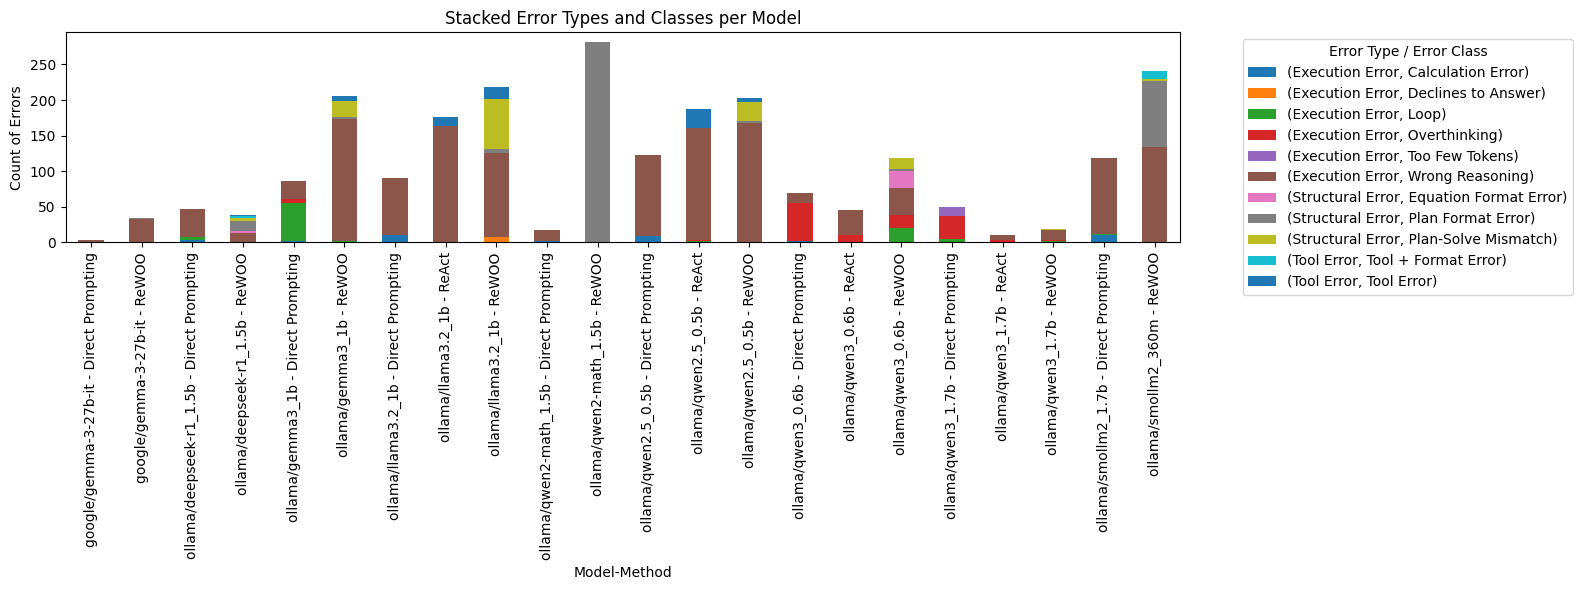

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# Set index to "Model" to prepare for plotting
df_plot = df_err.set_index("Model-Method")

# Plot as stacked bar chart
df_plot.plot(kind="bar", stacked=True, figsize=(12, 6))

plt.ylabel("Count of Errors")
plt.title("Stacked Error Types and Classes per Model")
plt.xticks(rotation=90)
plt.tight_layout()
plt.legend(title="Error Type / Error Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Per Operation Type

In [67]:
# Filter df by unique ids and collect number of unique question types
def get_question_type_mapping():
    seen_ids = set()
    question_type_mapping = {}
    for _, row in df.iterrows():
        if row['ID'] not in seen_ids:
            seen_ids.add(row['ID'])
            if row['Type'] not in question_type_mapping:
                question_type_mapping[row['Type']] = 0
            question_type_mapping[row['Type']] += 1
    return question_type_mapping

question_type_mapping = get_question_type_mapping()

# Convert to a DataFrame for better visualization
question_type_df = pd.DataFrame(list(question_type_mapping.items()), columns=['Question Type', 'Count'])
question_type_df = question_type_df.sort_values(by='Count', ascending=False)
question_type_df

,Question Type,Count
0,Subtraction,153
3,Addition,55
1,Common-Division,44
2,Multiplication,32


In [72]:
qtypes_df = df.groupby(["Model", "Method", "Type"]).agg({
    "is_correct": "sum"
}).reset_index()

qtypes_df["Total_Questions"] = qtypes_df["Type"].map(lambda x: question_type_mapping.get(x, 0))
qtypes_df["Correct_Score"] = qtypes_df["is_correct"] / qtypes_df["Total_Questions"] * 100

qtypes_df

,Model,Method,Type,is_correct,Total_Questions,Correct_Score
0,google/gemma-3-27b-it,Direct Prompting,Addition,54,55,98.181818
1,google/gemma-3-27b-it,Direct Prompting,Common-Division,43,44,97.727273
2,google/gemma-3-27b-it,Direct Prompting,Multiplication,32,32,100.0
3,google/gemma-3-27b-it,Direct Prompting,Subtraction,152,153,99.346405
4,google/gemma-3-27b-it,ReWOO,Addition,48,55,87.272727
...,...,...,...,...,...,...
83,ollama/smollm2_1.7b,Direct Prompting,Subtraction,85,153,55.555556
84,ollama/smollm2_360m,ReWOO,Addition,6,55,10.909091
85,ollama/smollm2_360m,ReWOO,Common-Division,6,44,13.636364
86,ollama/smollm2_360m,ReWOO,Multiplication,3,32,9.375


In [73]:
qtypes_df.to_records()

rec.array([( 0, 'google/gemma-3-27b-it', 'Direct Prompting', 'Addition', 54,  55, 98.18181818181819),
           ( 1, 'google/gemma-3-27b-it', 'Direct Prompting', 'Common-Division', 43,  44, 97.72727272727273),
           ( 2, 'google/gemma-3-27b-it', 'Direct Prompting', 'Multiplication', 32,  32, 100.0),
           ( 3, 'google/gemma-3-27b-it', 'Direct Prompting', 'Subtraction', 152, 153, 99.34640522875817),
           ( 4, 'google/gemma-3-27b-it', 'ReWOO', 'Addition', 48,  55, 87.27272727272727),
           ( 5, 'google/gemma-3-27b-it', 'ReWOO', 'Common-Division', 36,  44, 81.81818181818183),
           ( 6, 'google/gemma-3-27b-it', 'ReWOO', 'Multiplication', 30,  32, 93.75),
           ( 7, 'google/gemma-3-27b-it', 'ReWOO', 'Subtraction', 136, 153, 88.88888888888889),
           ( 8, 'ollama/deepseek-r1_1.5b', 'Direct Prompting', 'Addition', 50,  55, 90.9090909090909),
           ( 9, 'ollama/deepseek-r1_1.5b', 'Direct Prompting', 'Common-Division', 35,  44, 79.54545454545455),
    

In [85]:
significant_results = []
n = df["ID"].nunique()
data = {}
headers = qtypes_df.columns.tolist()[:-1]

for item in qtypes_df.to_records():
    model = item[1]
    method = item[2]
    operation = item[3]
    is_correct = item[4]
    count = item[5]
    correct_score = item[6]

    if model not in data:
        data[model] = {}
    if operation not in data[model]:
        data[model][operation] = []
    item = (model, method, operation, is_correct, count, correct_score)
    data[model][operation].append(item)

for model in data:
    operations = list(data[model].keys())
    for operation in operations:
        items = data[model][operation]
        for i in range(len(items)):
            for j in range(i + 1, len(items)):
                method1 = items[i][1]
                method2 = items[j][1]
                score1 = items[i][5]/100
                score2 = items[j][5]/100
                n1 = items[i][4]
                n2 = items[j][4]

                if method1 == method2:
                    continue
                r = compare_accuracies_v3(
                    p1=score1,
                    n1=n1,
                    p2=score2,
                    n2=n2
                )
                # print(f"Comparing {method1} vs {method2} for {headers[k]} in {model}: {score1} vs {score2} => is_significant: {r.is_significant}")
                if r.is_significant:
                    if score1 < score2:
                        method1, score1, method2, score2 = method2, score2, method1, score1
                    significant_results.append({
                        "model": model,
                        "Operation": operation,
                        "method1": method1,
                        "score1": score1,
                        "method2": method2,
                        "score2": score2,
                        "is_significant": r.is_significant,
                    })
                        
                
                
significant_results_df = pd.DataFrame.from_records(significant_results)
# Drop all rows where score1 or score2 is 0
significant_results_df = significant_results_df[(significant_results_df["score1"] > 0) & (significant_results_df["score2"] > 0)]

significant_results_df

,model,Operation,method1,score1,method2,score2,is_significant
0,google/gemma-3-27b-it,Addition,Direct Prompting,0.981818,ReWOO,0.872727,True
1,google/gemma-3-27b-it,Common-Division,Direct Prompting,0.977273,ReWOO,0.818182,True
2,google/gemma-3-27b-it,Subtraction,Direct Prompting,0.993464,ReWOO,0.888889,True
3,ollama/gemma3_1b,Addition,Direct Prompting,0.636364,ReWOO,0.218182,True
4,ollama/gemma3_1b,Common-Division,Direct Prompting,0.750000,ReWOO,0.318182,True
5,ollama/gemma3_1b,Multiplication,Direct Prompting,0.687500,ReWOO,0.187500,True
6,ollama/gemma3_1b,Subtraction,Direct Prompting,0.699346,ReWOO,0.300654,True
7,ollama/llama3.2_1b,Addition,Direct Prompting,0.636364,ReAct,0.436364,True
8,ollama/llama3.2_1b,Addition,Direct Prompting,0.636364,ReWOO,0.181818,True
9,ollama/llama3.2_1b,Addition,ReAct,0.436364,ReWOO,0.181818,True


# Question Type

In [86]:
# Different question types
def classify_question_type(question):
    if "how many more" in question.lower():
        return "How Many More"
    elif "how many" in question.lower():
        return "How Many"
    elif "how much" in question.lower():
        return "How Much"
    elif "how big" in question.lower():
        return "How Big"
    elif "how long" in question.lower():
        return "How Long"
    elif "what is" in question.lower():
        return "What is"
    elif "how deep" in question.lower():
        return "How Deep"
    elif "how far" in question.lower():
        return "How Far"
    return np.nan

df_qt = df.copy()
df_qt['Question_Type'] = df['Question-only'].apply(classify_question_type)
print("NAN Question Types:", df_qt['Question_Type'].isna().sum())

# show ten questions with NaN question types
for question in df_qt[df_qt['Question_Type'].isna()]['question']:
    print(question)

# Filter df by unique ids and collect number of unique question types
def get_question_type_mapping():
    seen_ids = set()
    question_type_mapping = {}
    for _, row in df_qt.iterrows():
        if row['ID'] not in seen_ids:
            seen_ids.add(row['ID'])
            if row['Question_Type'] not in question_type_mapping:
                question_type_mapping[row['Question_Type']] = 0
            question_type_mapping[row['Question_Type']] += 1
    return question_type_mapping

question_type_mapping = get_question_type_mapping()

question_type_df = pd.DataFrame(list(question_type_mapping.items()), columns=['Question Type', 'Count'])
question_type_df = question_type_df.sort_values(by='Count', ascending=False)
question_type_df

NAN Question Types: 0


,Question Type,Count
1,How Many,166
0,How Many More,75
2,How Much,33
3,How Big,3
4,What is,2
5,How Long,2
7,How Far,2
6,How Deep,1


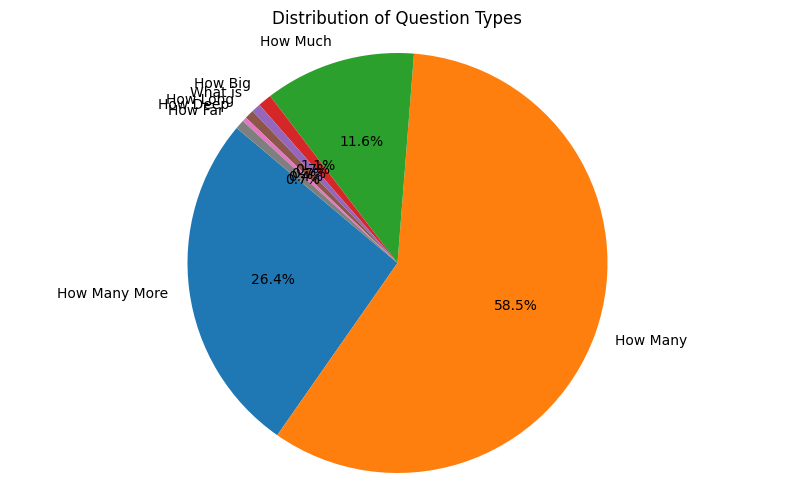

In [88]:
# Make a pie chart of the question types
import matplotlib.pyplot as plt
question_types = list(question_type_mapping.keys())
question_counts = list(question_type_mapping.values())
plt.figure(figsize=(10, 6))
plt.pie(question_counts, labels=question_types, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Question Types')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [87]:
qtypes_df = df_qt.groupby(["Model", "Question_Type"]).agg({
    "is_correct": "sum"
}).reset_index()

qtypes_df["Total_Questions"] = qtypes_df["Question_Type"].map(lambda x: question_type_mapping.get(x, 0))
qtypes_df["Correct_Score"] = qtypes_df["is_correct"] / qtypes_df["Total_Questions"] * 100
qtypes_pivot = qtypes_df.pivot_table(index='Question_Type', columns='Model', values='Correct_Score', fill_value=0)
qtypes_pivot

/var/folders/rl/3ygx2m4n1w747bxzh4qvfjs00000gn/T/ipykernel_5429/3781238049.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  qtypes_pivot = qtypes_df.pivot_table(index='Question_Type', columns='Model', values='Correct_Score', fill_value=0)


Model,google/gemma-3-27b-it,ollama/deepseek-r1_1.5b,ollama/gemma3_1b,ollama/llama3.2_1b,ollama/qwen2-math_1.5b,ollama/qwen2.5_0.5b,ollama/qwen3_0.6b,ollama/qwen3_1.7b,ollama/smollm2_1.7b,ollama/smollm2_360m
Question_Type,,,,,,,,,,
How Big,200.000000,166.666667,133.333333,133.333333,100.000000,233.333333,200.000000,266.666667,66.666667,0.000000
How Deep,200.000000,200.000000,100.000000,100.000000,100.000000,100.000000,300.000000,300.000000,100.000000,0.000000
How Far,200.000000,200.000000,100.000000,100.000000,100.000000,100.000000,300.000000,250.000000,0.000000,0.000000
How Long,200.000000,200.000000,100.000000,150.000000,100.000000,150.000000,250.000000,300.000000,50.000000,0.000000
How Many,186.746988,175.903614,95.783133,135.542169,96.385542,131.927711,221.686747,271.084337,61.445783,15.060241
How Many More,184.000000,161.333333,93.333333,116.000000,93.333333,82.666667,217.333333,280.000000,52.000000,20.000000
How Much,190.909091,154.545455,103.030303,130.303030,87.878788,118.181818,203.030303,254.545455,54.545455,6.060606
What is,200.000000,200.000000,150.000000,150.000000,100.000000,250.000000,250.000000,300.000000,100.000000,50.000000


# Token Usage

In [91]:
mean_token_usage = df.groupby(["Model", "Method"]).agg(
    mean_correct_answers=("is_correct", "mean"),
    mean_input_tokens=("input_tokens", "mean"),
    mean_output_tokens=("output_tokens", "mean"),
    mean_total_tokens=("total_tokens", "mean"),
)
mean_token_usage

mean_correct_answers  \
Model                   Method                                  
google/gemma-3-27b-it   Direct Prompting             0.989437   
                        ReWOO                        0.880282   
ollama/deepseek-r1_1.5b Direct Prompting             0.834507   
                        ReWOO                        0.866197   
ollama/gemma3_1b        Direct Prompting             0.693662   
                        ReWOO                        0.274648   
ollama/llama3.2_1b      Direct Prompting             0.683099   
                        ReAct                        0.380282   
                        ReWOO                        0.232394   
ollama/qwen2-math_1.5b  Direct Prompting              0.93662   
                        ReWOO                        0.010563   
ollama/qwen2.5_0.5b     Direct Prompting             0.566901   
                        ReAct                        0.338028   
                        ReWOO                        0.285211   
ollama/qwen3_0.6b       Direct Prompting             0.757042   
                        ReAct                        0.841549   
                        ReWOO                         0.59507   
ollama/qwen3_1.7b       Direct Prompting             0.823944   
                        ReAct                        0.961268   
                        ReWOO                        0.933099   
ollama/smollm2_1.7b     Direct Prompting             0.580986   
ollama/smollm2_360m     ReWOO                        0.151408   

                                          mean_input_tokens  \
Model                   Method                                
google/gemma-3-27b-it   Direct Prompting                NaN   
                        ReWOO                    742.306338   
ollama/deepseek-r1_1.5b Direct Prompting          44.584507   
                        ReWOO                    692.024648   
ollama/gemma3_1b        Direct Prompting          49.880282   
                        ReWOO                    737.940141   
ollama/llama3.2_1b      Direct Prompting          64.119718   
                        ReAct                    622.605634   
                        ReWOO                    694.014085   
ollama/qwen2-math_1.5b  Direct Prompting          47.584507   
                        ReWOO                    515.042254   
ollama/qwen2.5_0.5b     Direct Prompting          70.584507   
                        ReAct                    988.922535   
                        ReWOO                    769.735915   
ollama/qwen3_0.6b       Direct Prompting          49.584507   
                        ReAct                    527.172535   
                        ReWOO                    679.469965   
ollama/qwen3_1.7b       Direct Prompting          49.584507   
                        ReAct                   1041.792254   
                        ReWOO                    688.731449   
ollama/smollm2_1.7b     Direct Prompting          70.577465   
ollama/smollm2_360m     ReWOO                    742.686620   

                                          mean_output_tokens  \
Model                   Method                                 
google/gemma-3-27b-it   Direct Prompting                 NaN   
                        ReWOO                       0.000000   
ollama/deepseek-r1_1.5b Direct Prompting          325.528169   
                        ReWOO                     984.982394   
ollama/gemma3_1b        Direct Prompting          697.802817   
                        ReWOO                     111.070423   
ollama/llama3.2_1b      Direct Prompting           98.278169   
                        ReAct                      60.985915   
                        ReWOO                      50.471831   
ollama/qwen2-math_1.5b  Direct Prompting          203.021127   
                        ReWOO                     247.031690   
ollama/qwen2.5_0.5b     Direct Prompting          212.253521   
                        ReAct                      84.246479   
       

In [5]:
df[df["is_correct"] == True].groupby(["Model", "Method"]).agg(
    mean_correct_answers=("is_correct", "mean"),
    mean_input_tokens=("input_tokens", "mean"),
    mean_output_tokens=("output_tokens", "mean"),
    mean_total_tokens=("total_tokens", "mean"),
)

mean_correct_answers  \
Model                   Method                                  
google/gemma-3-27b-it   Direct Prompting                  1.0   
                        ReWOO                             1.0   
ollama/deepseek-r1_1.5b Direct Prompting                  1.0   
ollama/gemma3_1b        Direct Prompting                  1.0   
                        ReWOO                             1.0   
ollama/llama3.2_1b      Direct Prompting                  1.0   
                        ReWOO                             1.0   
ollama/qwen2-math_1.5b  Direct Prompting                  1.0   
                        ReWOO                             1.0   
ollama/qwen2.5_0.5b     Direct Prompting                  1.0   
                        ReAct                             1.0   
                        ReWOO                             1.0   
ollama/qwen3_0.6b       Direct Prompting                  1.0   
                        ReAct                             1.0   
                        ReWOO                             1.0   
ollama/qwen3_1.7b       Direct Prompting                  1.0   
                        ReAct                             1.0   
                        ReWOO                             1.0   
ollama/smollm2_1.7b     Direct Prompting                  1.0   
ollama/smollm2_360m     Direct Prompting                  1.0   

                                          mean_input_tokens  \
Model                   Method                                
google/gemma-3-27b-it   Direct Prompting                NaN   
                        ReWOO                    726.332000   
ollama/deepseek-r1_1.5b Direct Prompting          43.324895   
ollama/gemma3_1b        Direct Prompting          47.868020   
                        ReWOO                    724.685714   
ollama/llama3.2_1b      Direct Prompting          62.432990   
                        ReWOO                    695.787879   
ollama/qwen2-math_1.5b  Direct Prompting          47.116541   
                        ReWOO                    653.000000   
ollama/qwen2.5_0.5b     Direct Prompting          67.906832   
                        ReAct                    936.416667   
                        ReWOO                    751.111111   
ollama/qwen3_0.6b       Direct Prompting          47.953704   
                        ReAct                    517.112971   
                        ReWOO                    723.804734   
ollama/qwen3_1.7b       Direct Prompting          48.430328   
                        ReAct                   1040.556777   
                        ReWOO                    690.848485   
ollama/smollm2_1.7b     Direct Prompting          67.993939   
ollama/smollm2_360m     Direct Prompting          71.238806   

                                          mean_output_tokens  \
Model                   Method                                 
google/gemma-3-27b-it   Direct Prompting                 NaN   
                        ReWOO                       0.000000   
ollama/deepseek-r1_1.5b Direct Prompting          286.548523   
ollama/gemma3_1b        Direct Prompting          323.928934   
                        ReWOO                      86.557143   
ollama/llama3.2_1b      Direct Prompting           81.932990   
                        ReWOO                      46.878788   
ollama/qwen2-math_1.5b  Direct Prompting          191.751880   
                        ReWOO                     389.000000   
ollama/qwen2.5_0.5b     Direct Prompting          184.031056   
                        ReAct                      66.989583   
                        ReWOO                      95.111111   
ollama/qwen3_0.6b       Direct Prompting          818.819444   
                        ReAct                     371.104603   
                        ReWOO                     984.615385   
ollama/qwen3_1.7b       Direct Prompting         1191.672131   
                        ReAct                     507.978022   
       

In [90]:
df[df["is_correct"] == False].groupby(["Model", "Method"]).agg(
    mean_correct_answers=("is_correct", "mean"),
    mean_input_tokens=("input_tokens", "mean"),
    mean_output_tokens=("output_tokens", "mean"),
    mean_total_tokens=("total_tokens", "mean"),
)

mean_correct_answers  \
Model                   Method                                  
google/gemma-3-27b-it   Direct Prompting                  0.0   
                        ReWOO                             0.0   
ollama/deepseek-r1_1.5b Direct Prompting                  0.0   
                        ReWOO                             0.0   
ollama/gemma3_1b        Direct Prompting                  0.0   
                        ReWOO                             0.0   
ollama/llama3.2_1b      Direct Prompting                  0.0   
                        ReAct                             0.0   
                        ReWOO                             0.0   
ollama/qwen2-math_1.5b  Direct Prompting                  0.0   
                        ReWOO                             0.0   
ollama/qwen2.5_0.5b     Direct Prompting                  0.0   
                        ReAct                             0.0   
                        ReWOO                             0.0   
ollama/qwen3_0.6b       Direct Prompting                  0.0   
                        ReAct                             0.0   
                        ReWOO                             0.0   
ollama/qwen3_1.7b       Direct Prompting                  0.0   
                        ReAct                             0.0   
                        ReWOO                             0.0   
ollama/smollm2_1.7b     Direct Prompting                  0.0   
ollama/smollm2_360m     ReWOO                             0.0   

                                          mean_input_tokens  \
Model                   Method                                
google/gemma-3-27b-it   Direct Prompting                NaN   
                        ReWOO                    859.764706   
ollama/deepseek-r1_1.5b Direct Prompting          50.936170   
                        ReWOO                    657.157895   
ollama/gemma3_1b        Direct Prompting          54.436782   
                        ReWOO                    742.786408   
ollama/llama3.2_1b      Direct Prompting          67.755556   
                        ReAct                    622.835227   
                        ReWOO                    693.477064   
ollama/qwen2-math_1.5b  Direct Prompting          54.500000   
                        ReWOO                    513.569395   
ollama/qwen2.5_0.5b     Direct Prompting          74.089431   
                        ReAct                   1015.734043   
                        ReWOO                    777.167488   
ollama/qwen3_0.6b       Direct Prompting          55.000000   
                        ReAct                    580.600000   
                        ReWOO                    613.745614   
ollama/qwen3_1.7b       Direct Prompting          56.360000   
                        ReAct                   1072.454545   
                        ReWOO                    659.315789   
ollama/smollm2_1.7b     Direct Prompting          74.159664   
ollama/smollm2_360m     ReWOO                    730.282158   

                                          mean_output_tokens  \
Model                   Method                                 
google/gemma-3-27b-it   Direct Prompting                 NaN   
                        ReWOO                       0.000000   
ollama/deepseek-r1_1.5b Direct Prompting          522.085106   
                        ReWOO                    1581.710526   
ollama/gemma3_1b        Direct Prompting         1544.390805   
                        ReWOO                     120.359223   
ollama/llama3.2_1b      Direct Prompting          133.511111   
                        ReAct                      57.181818   
                        ReWOO                      51.559633   
ollama/qwen2-math_1.5b  Direct Prompting          369.555556   
                        ReWOO                     245.516014   
ollama/qwen2.5_0.5b     Direct Prompting          249.195122   
                        ReAct                      93.058511   
       